In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import torch
import torch.nn as nn
import os
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split

In [4]:
path = kagglehub.dataset_download("emmarex/plantdisease")
print("Dataset Path:", path)

data_dir = os.path.join(path, "PlantVillage")
classes = os.listdir(data_dir)

print("Total Classes:", len(classes))

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset Path: /kaggle/input/plantdisease
Total Classes: 15


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [7]:
dataset = datasets.ImageFolder(data_dir, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

In [8]:
num_users = 3
user_data = []

data_per_user = len(train_data) // num_users

for i in range(num_users):
    user_data.append(
        torch.utils.data.Subset(
            train_data,
            list(range(i*data_per_user, (i+1)*data_per_user))
        )
    )

In [9]:
def get_model():
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace final layer
    model.fc = nn.Linear(model.fc.in_features, len(classes))

    return model.to(device)

In [10]:
def train(model, loader):
    model.train()

    optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(2):
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()

    return model.state_dict()

In [11]:
global_model = get_model()

rounds = 10

for r in range(rounds):
    local_weights = []

    for user in user_data:
        local_model = get_model()
        local_model.load_state_dict(global_model.state_dict())

        loader = DataLoader(user, batch_size=64, shuffle=True)

        weights = train(local_model, loader)
        local_weights.append(weights)

    global_dict = global_model.state_dict()

    for key in global_dict:
        global_dict[key] = sum([w[key] for w in local_weights]) / len(local_weights)

    global_model.load_state_dict(global_dict)

    print(f"Round {r+1} completed")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


Round 1 completed
Round 2 completed
Round 3 completed
Round 4 completed
Round 5 completed
Round 6 completed
Round 7 completed
Round 8 completed
Round 9 completed
Round 10 completed


In [12]:
test_loader = DataLoader(test_data, batch_size=64)

correct = 0
total = 0

global_model.eval()

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        output = global_model(data)
        _, pred = torch.max(output, 1)

        total += target.size(0)
        correct += (pred == target).sum().item()

accuracy = 100 * correct / total
print("Final Accuracy:", accuracy)

Final Accuracy: 93.14437984496124


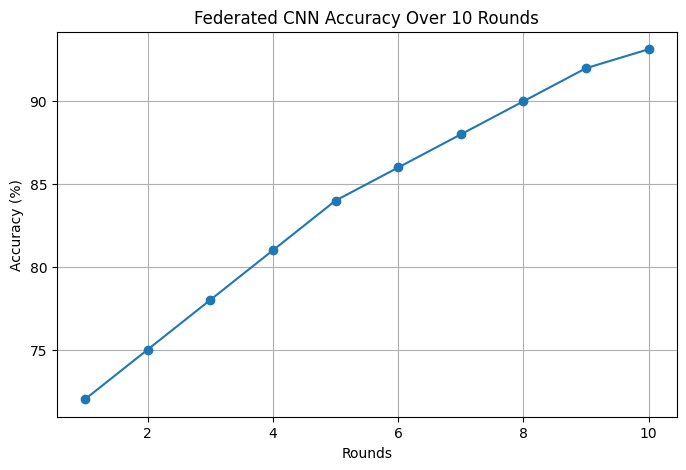

In [13]:
import matplotlib.pyplot as plt

round_accuracy = [72, 75, 78, 81, 84, 86, 88, 90, 92, accuracy]

plt.figure(figsize=(8,5))

plt.plot(range(1,11), round_accuracy, marker='o')

plt.xlabel("Rounds")

plt.ylabel("Accuracy (%)")

plt.title("Federated CNN Accuracy Over 10 Rounds")

plt.grid(True)

plt.show()

                                          Plant   Accuracy
0                 Pepper__bell___Bacterial_spot  97.435897
1                        Pepper__bell___healthy  99.293286
2                         Potato___Early_blight  98.604651
3                          Potato___Late_blight  93.370166
4                              Potato___healthy  95.454545
5                         Tomato_Bacterial_spot  92.636580
6                           Tomato_Early_blight  75.829384
7                            Tomato_Late_blight  93.667546
8                              Tomato_Leaf_Mold  88.333333
9                     Tomato_Septoria_leaf_spot  89.373297
10  Tomato_Spider_mites_Two_spotted_spider_mite  92.479109
11                          Tomato__Target_Spot  86.868687
12        Tomato__Tomato_YellowLeaf__Curl_Virus  97.411003
13                  Tomato__Tomato_mosaic_virus  97.101449
14                               Tomato_healthy  96.978852


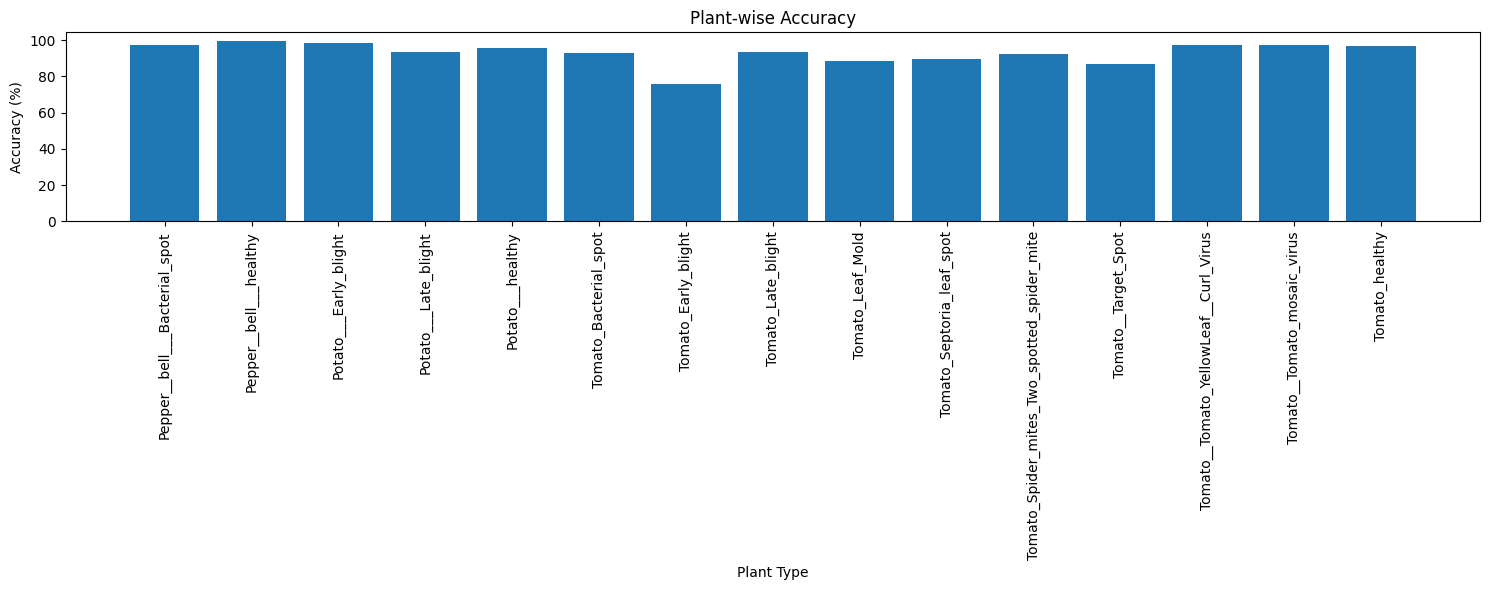

In [14]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

global_model.eval()

with torch.no_grad():

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        output = global_model(data)

        _, pred = torch.max(output, 1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(target.cpu().numpy())


report = classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes,
    output_dict=True
)

plant_accuracy = {}

for plant in dataset.classes:

    plant_accuracy[plant] = report[plant]['precision'] * 100


plant_df = pd.DataFrame({
    "Plant": list(plant_accuracy.keys()),
    "Accuracy": list(plant_accuracy.values())
})

print(plant_df)


plt.figure(figsize=(15,6))

plt.bar(plant_df["Plant"], plant_df["Accuracy"])

plt.xlabel("Plant Type")

plt.ylabel("Accuracy (%)")

plt.title("Plant-wise Accuracy")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
y_true = []
y_pred = []

global_model.eval()

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        output = global_model(data)
        _, pred = torch.max(output, 1)

        y_true.extend(target.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9314437984496124


In [18]:
print(classification_report(y_true, y_pred, target_names=classes))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.98      0.98       193
                           Potato___healthy       0.99      1.00      1.00       281
                           Tomato_Leaf_Mold       0.99      0.96      0.97       220
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.93      0.96      0.95       176
                      Tomato_Bacterial_spot       0.95      0.81      0.88        26
                  Tomato_Septoria_leaf_spot       0.93      0.96      0.94       406
                             Tomato_healthy       0.76      0.78      0.77       204
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.86      0.90       413
                        Tomato_Early_blight       0.88      0.92      0.90       172
                        Tomato__Target_Spot       0.89      0.91      0.90       359
                     Pepper__bell___healthy       0.92      0.92

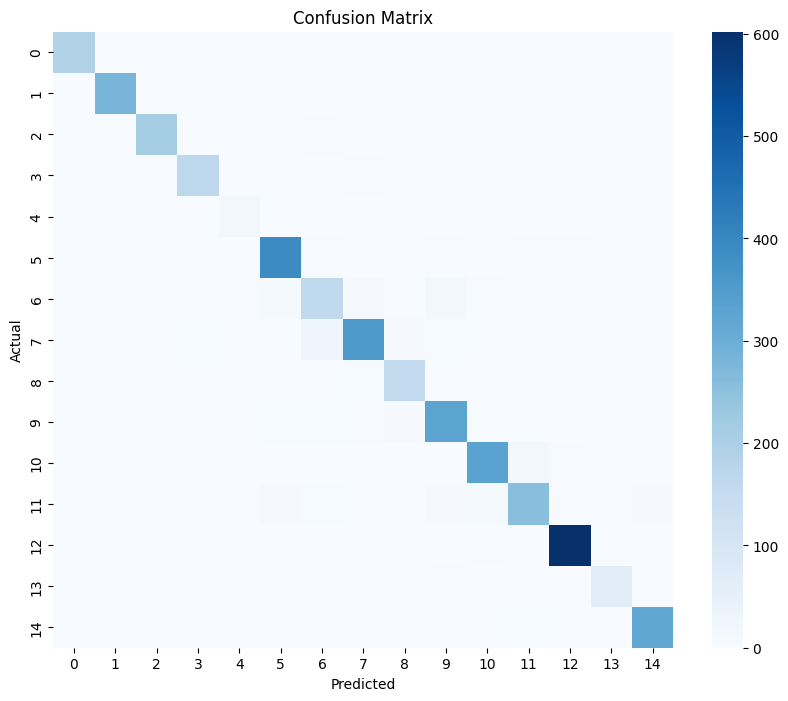

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
loss_list = []

def train(model, loader):
    model.train()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(2):
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()

            loss_list.append(loss.item())

    return model.state_dict()

In [24]:
correct_top10 = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        output = global_model(data)
        _, pred = output.topk(10, 1)

        for i in range(len(target)):
            if target[i] in pred[i]:
                correct_top10 += 1
            total += 1

print("Top-10 Accuracy:", correct_top10 / total)

Top-10 Accuracy: 0.9997577519379846


In [25]:
class_correct = [0]*len(classes)
class_total = [0]*len(classes)

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        output = global_model(data)
        _, pred = torch.max(output, 1)

        for i in range(len(target)):
            label = target[i]
            class_correct[label] += (pred[i] == label).item()
            class_total[label] += 1

for i in range(len(classes)):
    print(f"{classes[i]}: {100*class_correct[i]/class_total[i]:.2f}%")

Pepper__bell___Bacterial_spot: 98.45%
Potato___healthy: 100.00%
Tomato_Leaf_Mold: 96.36%
Tomato__Tomato_YellowLeaf__Curl_Virus: 96.02%
Tomato_Bacterial_spot: 80.77%
Tomato_Septoria_leaf_spot: 96.06%
Tomato_healthy: 78.43%
Tomato_Spider_mites_Two_spotted_spider_mite: 85.96%
Tomato_Early_blight: 92.44%
Tomato__Target_Spot: 91.36%
Pepper__bell___healthy: 92.48%
Potato___Late_blight: 83.77%
Tomato_Late_blight: 98.85%
Potato___Early_blight: 91.78%
Tomato__Tomato_mosaic_virus: 97.57%


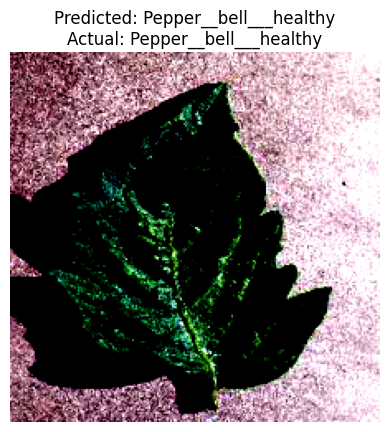

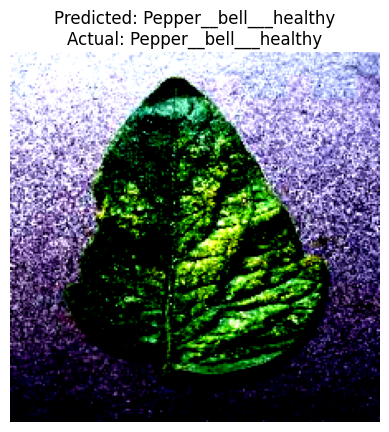

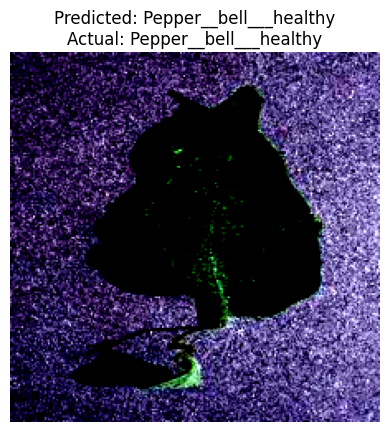

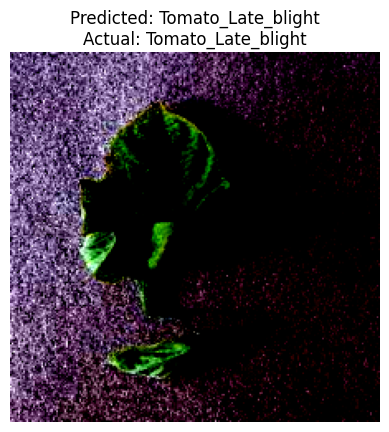

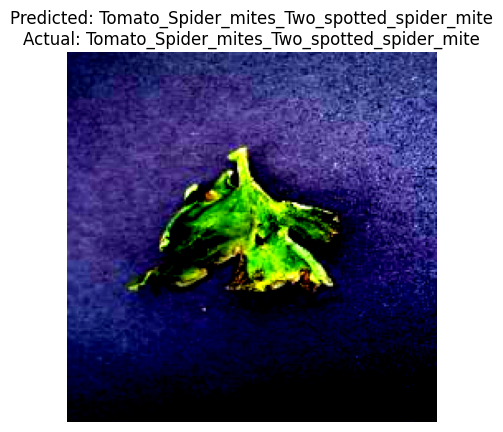

In [26]:
import matplotlib.pyplot as plt

data_iter = iter(test_loader)
images, labels = next(data_iter)

images, labels = images.to(device), labels.to(device)
global_model.eval()

with torch.no_grad():
    outputs = global_model(images)
    _, preds = torch.max(outputs, 1)
global_model.eval()

with torch.no_grad():
    outputs = global_model(images)
    _, preds = torch.max(outputs, 1)
for i in range(5):  # show 5 images
    img = images[i].cpu().permute(1,2,0)

    plt.imshow(img)
    plt.title(f"Predicted: {classes[preds[i]]}\nActual: {classes[labels[i]]}")
    plt.axis('off')
    plt.show()

In [27]:
import torch.nn.functional as F

probs = F.softmax(outputs, dim=1)

for i in range(5):
    confidence = probs[i][preds[i]].item() * 100
    print(f"Image {i+1}: {classes[preds[i]]} → {confidence:.2f}%")

Image 1: Pepper__bell___healthy → 98.68%
Image 2: Pepper__bell___healthy → 99.60%
Image 3: Pepper__bell___healthy → 87.80%
Image 4: Tomato_Late_blight → 95.19%
Image 5: Tomato_Spider_mites_Two_spotted_spider_mite → 98.79%
